In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [ ]:
# ==========================
# CONECTAR GOOGLE DRIVE
# ==========================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================
# CONFIGURACIÓN
# ==========================

DATASET_PATH = "/content/drive/MyDrive/dataset"
IMG_SIZE = 320
BATCH_SIZE = 8
EPOCHS = 10
NUM_CLASSES = 3

In [ ]:
# ==========================
# VERIFICAR DATASET
# ==========================

print("Carpetas encontradas en dataset:")
print(os.listdir(DATASET_PATH))

Carpetas encontradas en dataset:
['organico', 'no_reciclables', 'reciclable']


In [ ]:
# ==========================
# PREPROCESAMIENTO
# ==========================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True
)

# Datos de entrenamiento

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Datos de validación

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 235 images belonging to 3 classes.
Found 57 images belonging to 3 classes.


In [ ]:
# ==========================
# MODELO BASE
# ==========================

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

/tmp/ipykernel_384/1802159343.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ==========================
# MODELO FINAL
# ==========================

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
# ==========================
# COMPILACIÓN
# ==========================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 10, 10, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ==========================
# ENTRENAMIENTO
# ==========================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.8085 - loss: 0.4633 - val_accuracy: 0.9123 - val_loss: 0.2319
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9702 - loss: 0.0749 - val_accuracy: 0.9298 - val_loss: 0.1625
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9872 - loss: 0.0451 - val_accuracy: 0.8421 - val_loss: 0.3541
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9787 - loss: 0.0475 - val_accuracy: 0.9474 - val_loss: 0.0830
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 0.9649 - val_loss: 0.0494
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.9474 - val_loss: 0.1224
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9915 - loss: 0.0178 - val_accuracy: 0.9825 - val_loss: 0.0703
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 0.9649 - val_loss:

In [ ]:
# ==========================
# GUARDAR MODELO
# ==========================

model.save("/content/drive/MyDrive/modelo_basura_reentrenado.keras")

print("✅ Modelo guardado en Google Drive.")

✅ Modelo guardado en Google Drive.


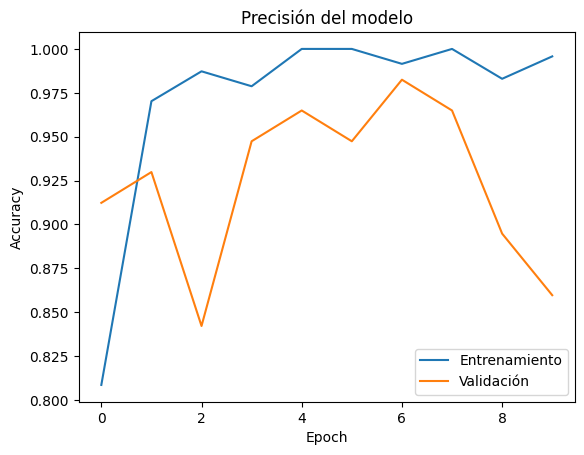

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Precisión del modelo')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'])
plt.show()